In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pylab import rcParams
import h5py
import seaborn as sns
from scipy.special import logit
from scipy.special import expit
from scipy.interpolate import RegularGridInterpolator
from pylab import rcParams
import sys
import torch
import scipy
import corner
import copy
from copy import deepcopy

import sys
sys.path.append('../')
from populations.bbh_models import read_hdf5
from populations.bbh_models import get_models
from populations.Pop_Flows import FlowModel
from populations.utils.bounded_Nd_kde import Bounded_Nd_kde

/data/wiay/2297403c/conda_envs/amaze/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#flags/inputs:
param = ['mchirp','q', 'chieff', 'z']
no_params = len(param)
channel_label = 'CE'

channel_ids = {'CE':0, 'CHE':1,'GC':2,'NSC':3, 'SMT':4}
channel_id = channel_ids[channel_label] #will be 0, 1, 2, 3, or 4
chi_b = [0.0,0.1,0.2,0.5]
alpha_CE = [0.2,0.5,1.0,2.,5.]

total_hps=20

models_path ='/data/wiay/2297403c/models_reduced.hdf5'
#models_path ='/Users/stormcolloms/Documents/PhD/Project_work/Onechannel_flows/models_reduced.hdf5'
flow_path = '/data/wiay/2297403c/amaze_model_select/AMAZE_project_resources/flow_models/mixedmodels_0924/'
popsynth_outputs = read_hdf5(models_path, channel_label) # read all data from hdf5 file

models_dict = dict.fromkeys(popsynth_outputs.keys())
weights_dict = dict.fromkeys(popsynth_outputs.keys())


for key in popsynth_outputs.keys():
    models_dict[key] = popsynth_outputs[key][param]
    weights_dict[key]= popsynth_outputs[key]['weight']


In [6]:
#check that these distributions are the same between the whole (transformed distribution), batch, and the same for validation data
#no_trans, no_neurons, training_inputs, cond_inputs,no_binaries, batch_size, total_hps, RNVP=True, num_bins=4, device="cpu"):
flow_path ='/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/inputs/flow_models/CE_test_population/'
flow = FlowModel(channel_label, popsynth_outputs, param, flow_path=flow_path, sensitivity='midhighlatelow_network', device='cpu')
model_names, KDE_models = get_models(models_path, [channel_label], param, use_flows=False, spin_distr=None, normalize=False, detectable=False)


  0%|          | 0/20 [00:00<?, ?it/s]OMP: Warning #96: Cannot form a team with 44 threads, using 42 instead.
OMP: Hint Consider unsetting KMP_DEVICE_THREAD_LIMIT (KMP_ALL_THREADS), KMP_TEAMS_THREAD_LIMIT, and OMP_THREAD_LIMIT (if any are set).
100%|██████████| 20/20 [01:40<00:00,  5.04s/it]


In [7]:
#inputs: x, data, pop_models, submodels_dict, channels, use_flows
hyperparams = list(set([x.split('/', 1)[1] for x in model_names]))
Nhyper = np.max([len(x.split('/')) for x in hyperparams])
channels = sorted(list(set([x.split('/')[0] for x in model_names])))

# construct dict that relates submodels to their index number
submodels_dict = {} #dummy index dict keys:0,1,2,3, items: particular models
ctr=0 #associates with either chi_b or alpha (0 or 1)
while ctr < Nhyper:
    submodels_dict[ctr] = {}
    hyper_set = sorted(list(set([x.split('/')[ctr] for x in hyperparams])))
    for idx, model in enumerate(hyper_set): #idx associates with 0,1,2,3,(4) keys
        submodels_dict[ctr][idx] = model
    ctr += 1

In [8]:
flow.load_model(flow_path)

## Unweighted flow distributions - nonCE

KeyboardInterrupt: 

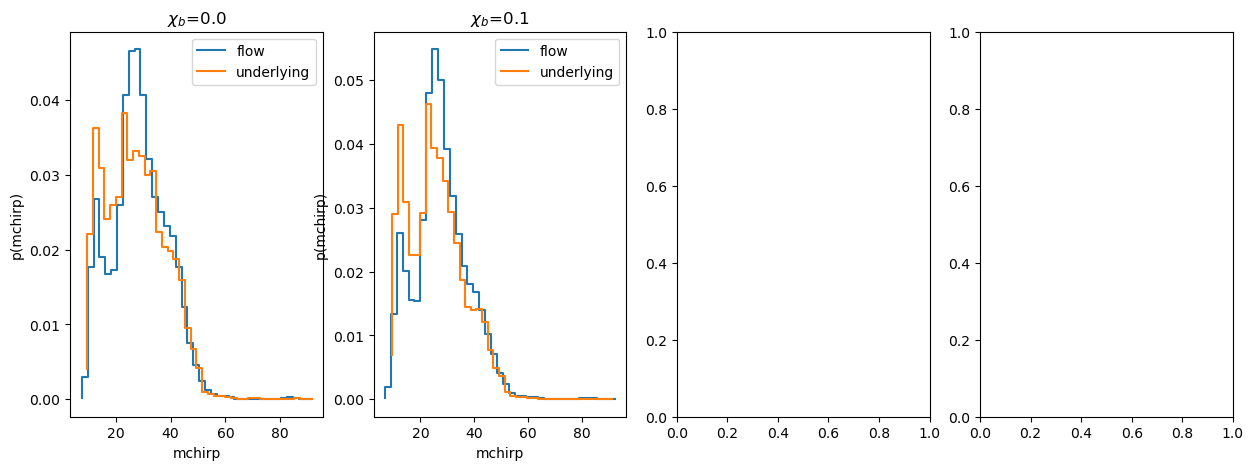

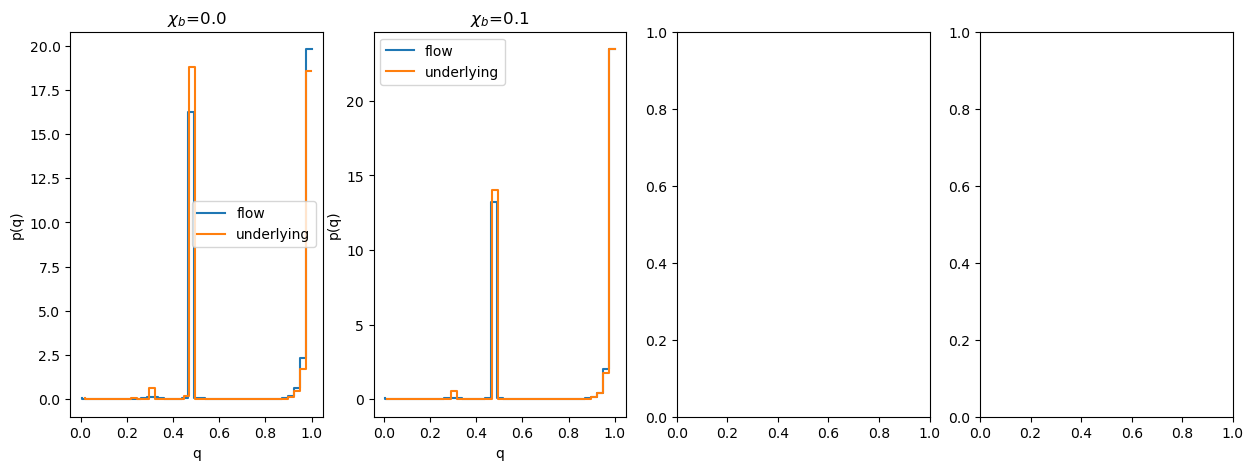

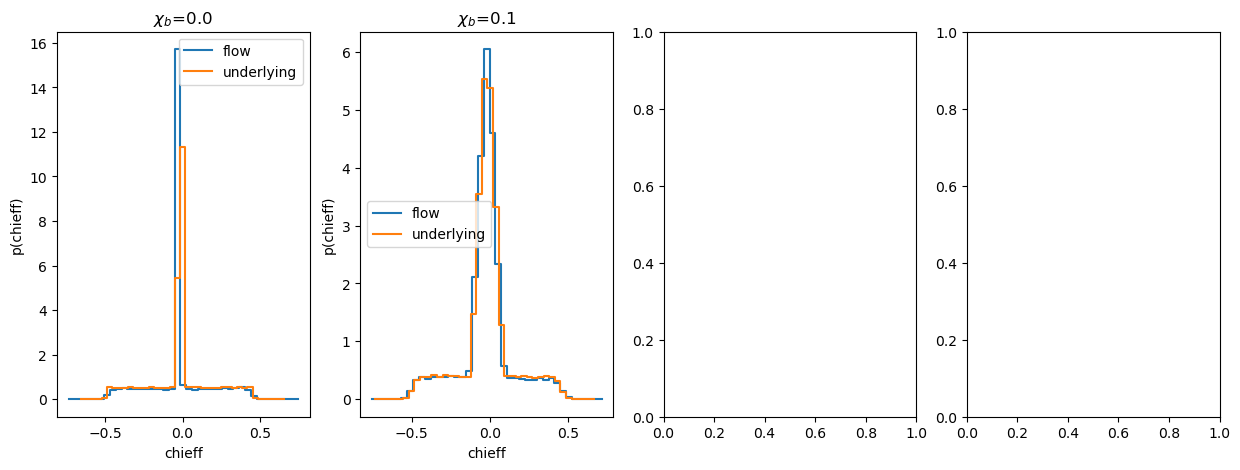

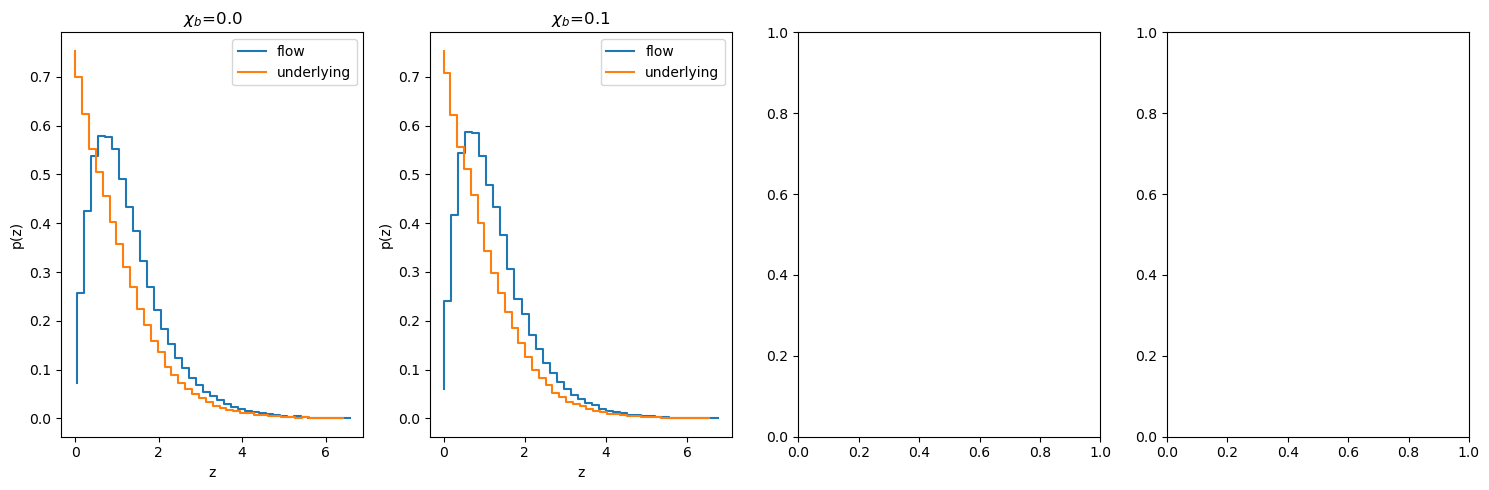

In [12]:
plt.rcParams["figure.figsize"] = (15,5)
no_samples = 100000
no_bins = 40

fig_mchirp, ax_m = plt.subplots(1,4)
fig_q, ax_q = plt.subplots(1,4)
fig_c, ax_c = plt.subplots(1,4)
fig_z, ax_z = plt.subplots(1,4)

for chi_b_id, xb in enumerate(chi_b):
    flow_samples_stack = flow.flow.sample(np.array([xb]),no_samples)
    flow_mchirp = flow.expistic(flow_samples_stack[:,0], flow.mappings[0], flow.mappings[1])
    flow_q = flow.expistic(flow_samples_stack[:,1], flow.mappings[2])
    flow_chieff = np.tanh(flow_samples_stack[:,2])
    flow_z = flow.expistic(flow_samples_stack[:,3], flow.mappings[4], flow.mappings[5])

    mapped_flow_samples = [flow_mchirp,flow_q,flow_chieff,flow_z]

    for i, ax in enumerate([ax_m,ax_q,ax_c,ax_z]):
        flow_distr, bin_edges = np.histogram(mapped_flow_samples[i], bins=no_bins, density=True)
        known_distr, bin_edges_known =np.histogram(models_dict[chi_b_id][:][param[i]], bins=no_bins, density=True)
        ax[chi_b_id].step(np.linspace(bin_edges[0],bin_edges[-1],no_bins),flow_distr, label='flow')
        ax[chi_b_id].step(np.linspace(bin_edges_known[0],bin_edges_known[-1],no_bins),known_distr,label='underlying')
        ax[chi_b_id].set_title(fr'$\chi_b$={xb}')
        ax[chi_b_id].set_xlabel(f'{param[i]}')
        ax[chi_b_id].set_ylabel(f'p({param[i]})')
        ax[chi_b_id].legend()
        plt.tight_layout()

## Weighted Flow distributions - nonCE

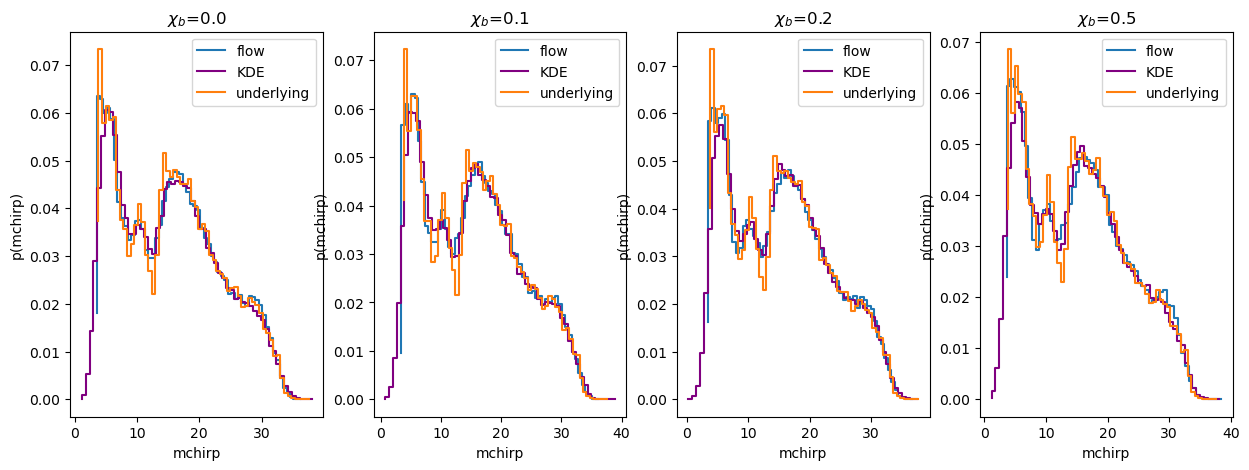

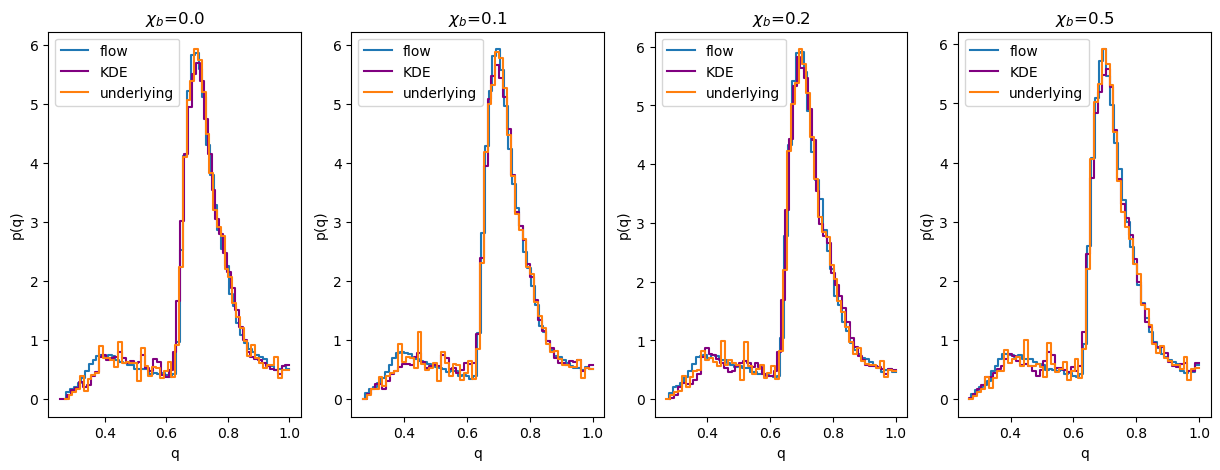

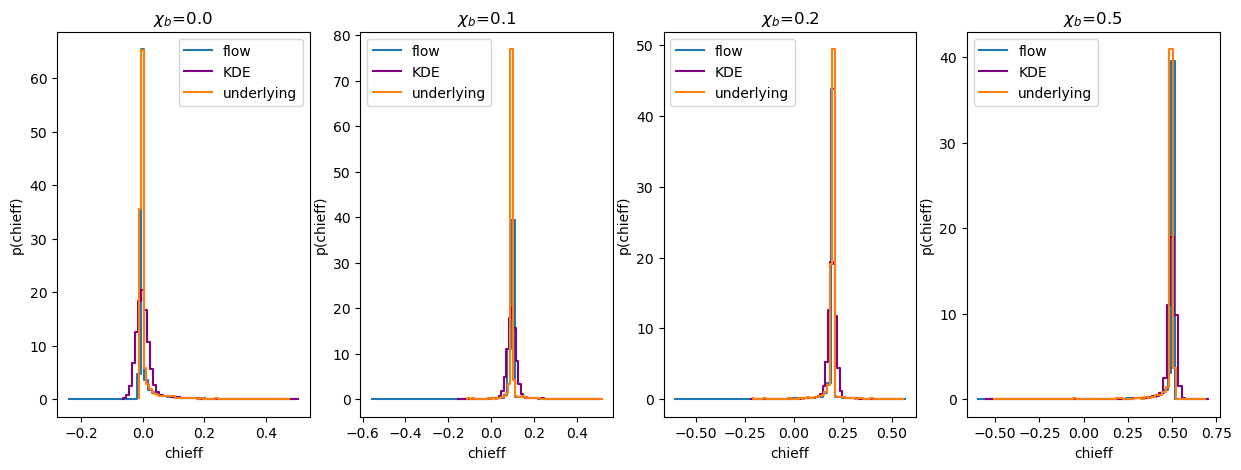

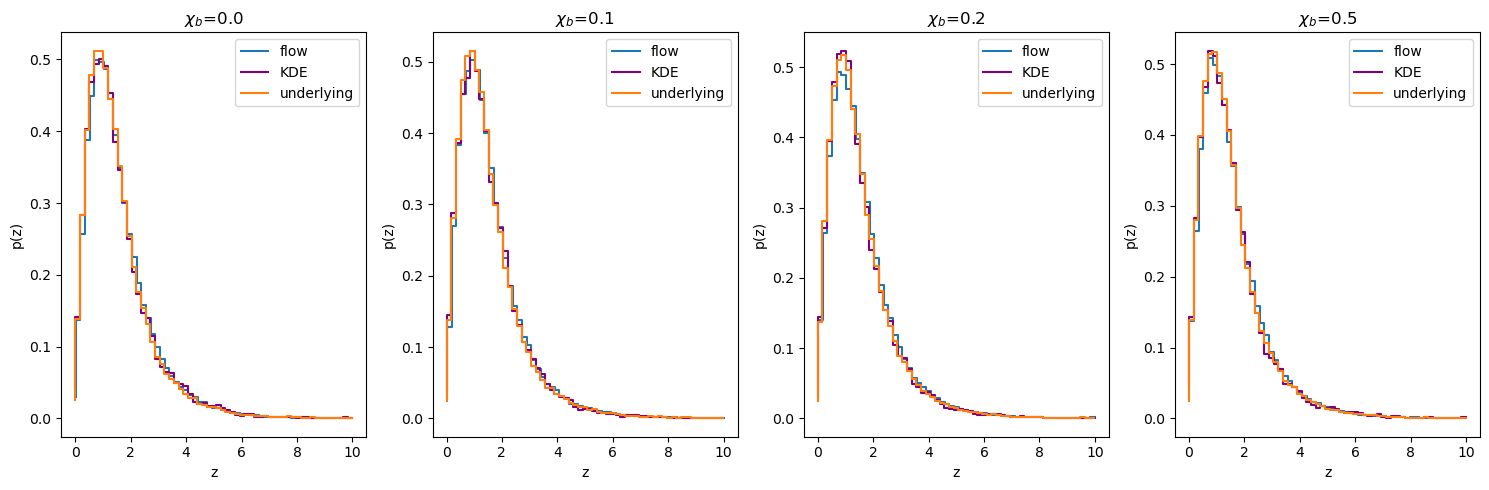

In [43]:
plt.rcParams["figure.figsize"] = (15,5)
no_samples = 100000
no_bins = 60

fig_mchirp, ax_m = plt.subplots(1,4)
fig_q, ax_q = plt.subplots(1,4)
fig_c, ax_c = plt.subplots(1,4)
fig_z, ax_z = plt.subplots(1,4)

for chi_b_id, xb in enumerate(chi_b):
    flow_samples_stack = flow.flow.sample(np.array([xb]),no_samples)
    flow_mchirp = flow.expistic(flow_samples_stack[:,0], flow.mappings[0], flow.mappings[1])
    flow_q = flow.expistic(flow_samples_stack[:,1], flow.mappings[2])
    flow_chieff = np.tanh(flow_samples_stack[:,2])
    flow_z = flow.expistic(flow_samples_stack[:,3], flow.mappings[4], flow.mappings[5])

    mapped_flow_samples = [flow_mchirp,flow_q,flow_chieff,flow_z]

    kde_samples = KDE_models[channel_label][submodels_dict[0][chi_b_id]].sample(no_samples)

    for i, ax in enumerate([ax_m,ax_q,ax_c,ax_z]):
        flow_distr, bin_edges = np.histogram(mapped_flow_samples[i], bins=no_bins, density=True)
        kde_distr, bin_edges_KDE = np.histogram(kde_samples[:,i], bins=no_bins, density=True)
        known_distr, bin_edges_known =np.histogram(models_dict[chi_b_id][:][param[i]], bins=no_bins, density=True, weights=weights_dict[chi_b_id])
        ax[chi_b_id].step(np.linspace(bin_edges[0],bin_edges[-1],no_bins),flow_distr, label='flow')
        ax[chi_b_id].step(np.linspace(bin_edges_KDE[0],bin_edges_KDE[-1],no_bins),kde_distr,label='KDE', color='purple')
        ax[chi_b_id].step(np.linspace(bin_edges_known[0],bin_edges_known[-1],no_bins),known_distr,label='underlying')
        ax[chi_b_id].set_title(fr'$\chi_b$={xb}')
        ax[chi_b_id].set_xlabel(f'{param[i]}')
        ax[chi_b_id].set_ylabel(f'p({param[i]})')
        #ax[chi_b_id].set_yscale('log')
        ax[chi_b_id].legend()
        plt.tight_layout()

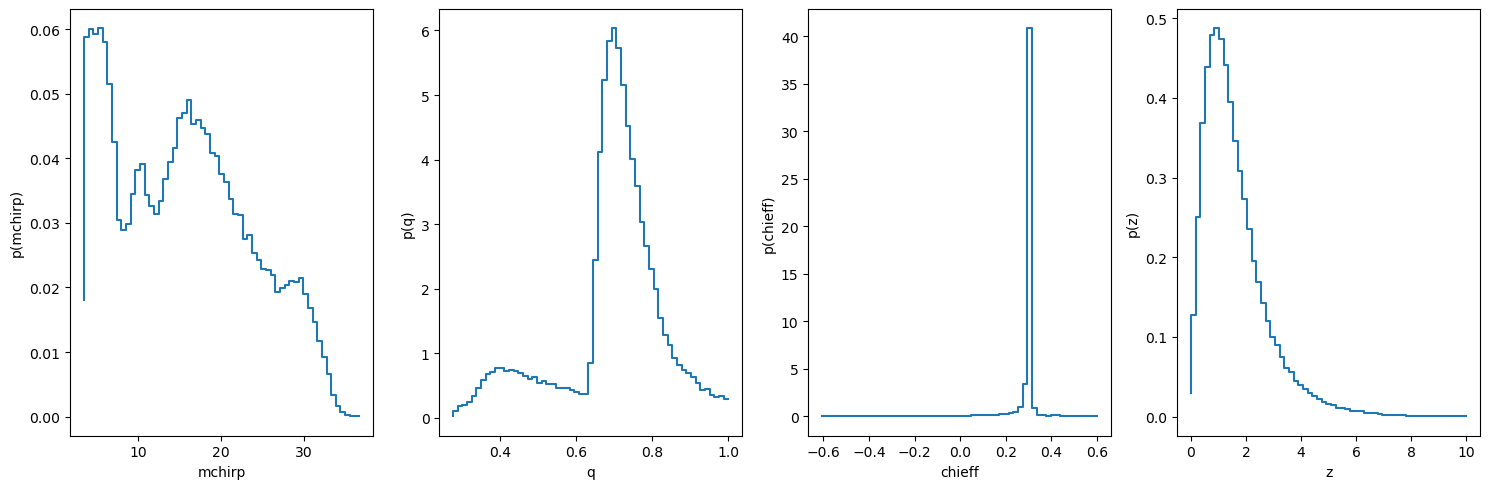

In [44]:
#checking example of flow interpolation
plt.rcParams["figure.figsize"] = (15,5)
no_samples = 100000
no_bins = 60

fig, ax = plt.subplots(1,4)

flow_samples_stack = flow.flow.sample(np.array([0.3]),no_samples)
flow_mchirp = flow.expistic(flow_samples_stack[:,0], flow.mappings[0], flow.mappings[1])
flow_q = flow.expistic(flow_samples_stack[:,1], flow.mappings[2])
flow_chieff = np.tanh(flow_samples_stack[:,2])
flow_z = flow.expistic(flow_samples_stack[:,3], flow.mappings[4], flow.mappings[5])

mapped_flow_samples = [flow_mchirp,flow_q,flow_chieff,flow_z]

for i, p in enumerate(param):
    flow_distr, bin_edges = np.histogram(mapped_flow_samples[i], bins=no_bins, density=True)
    ax[i].step(np.linspace(bin_edges[0],bin_edges[-1],no_bins),flow_distr, label='flow')
    ax[i].set_xlabel(f'{p}')
    ax[i].set_ylabel(f'p({p})')
    plt.tight_layout()

## Unweighted distributions - CE

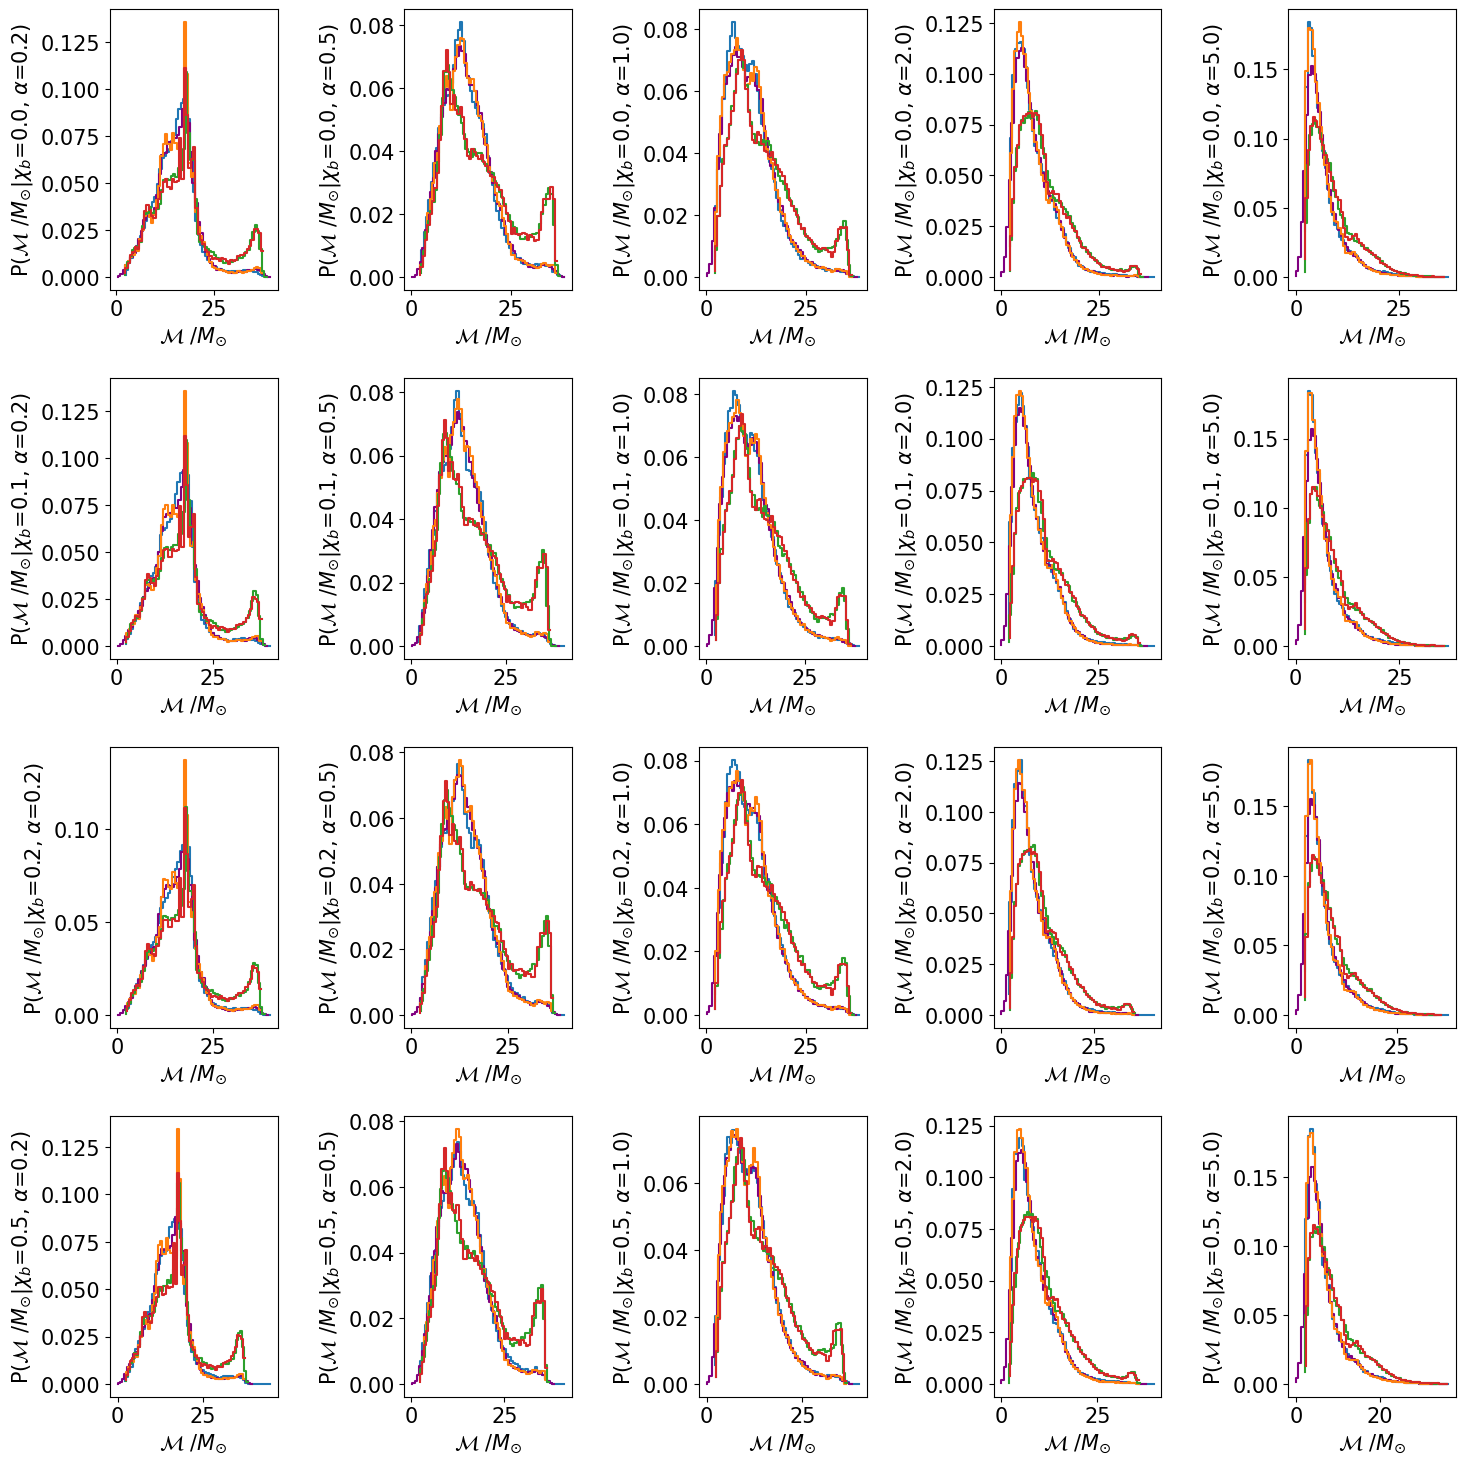

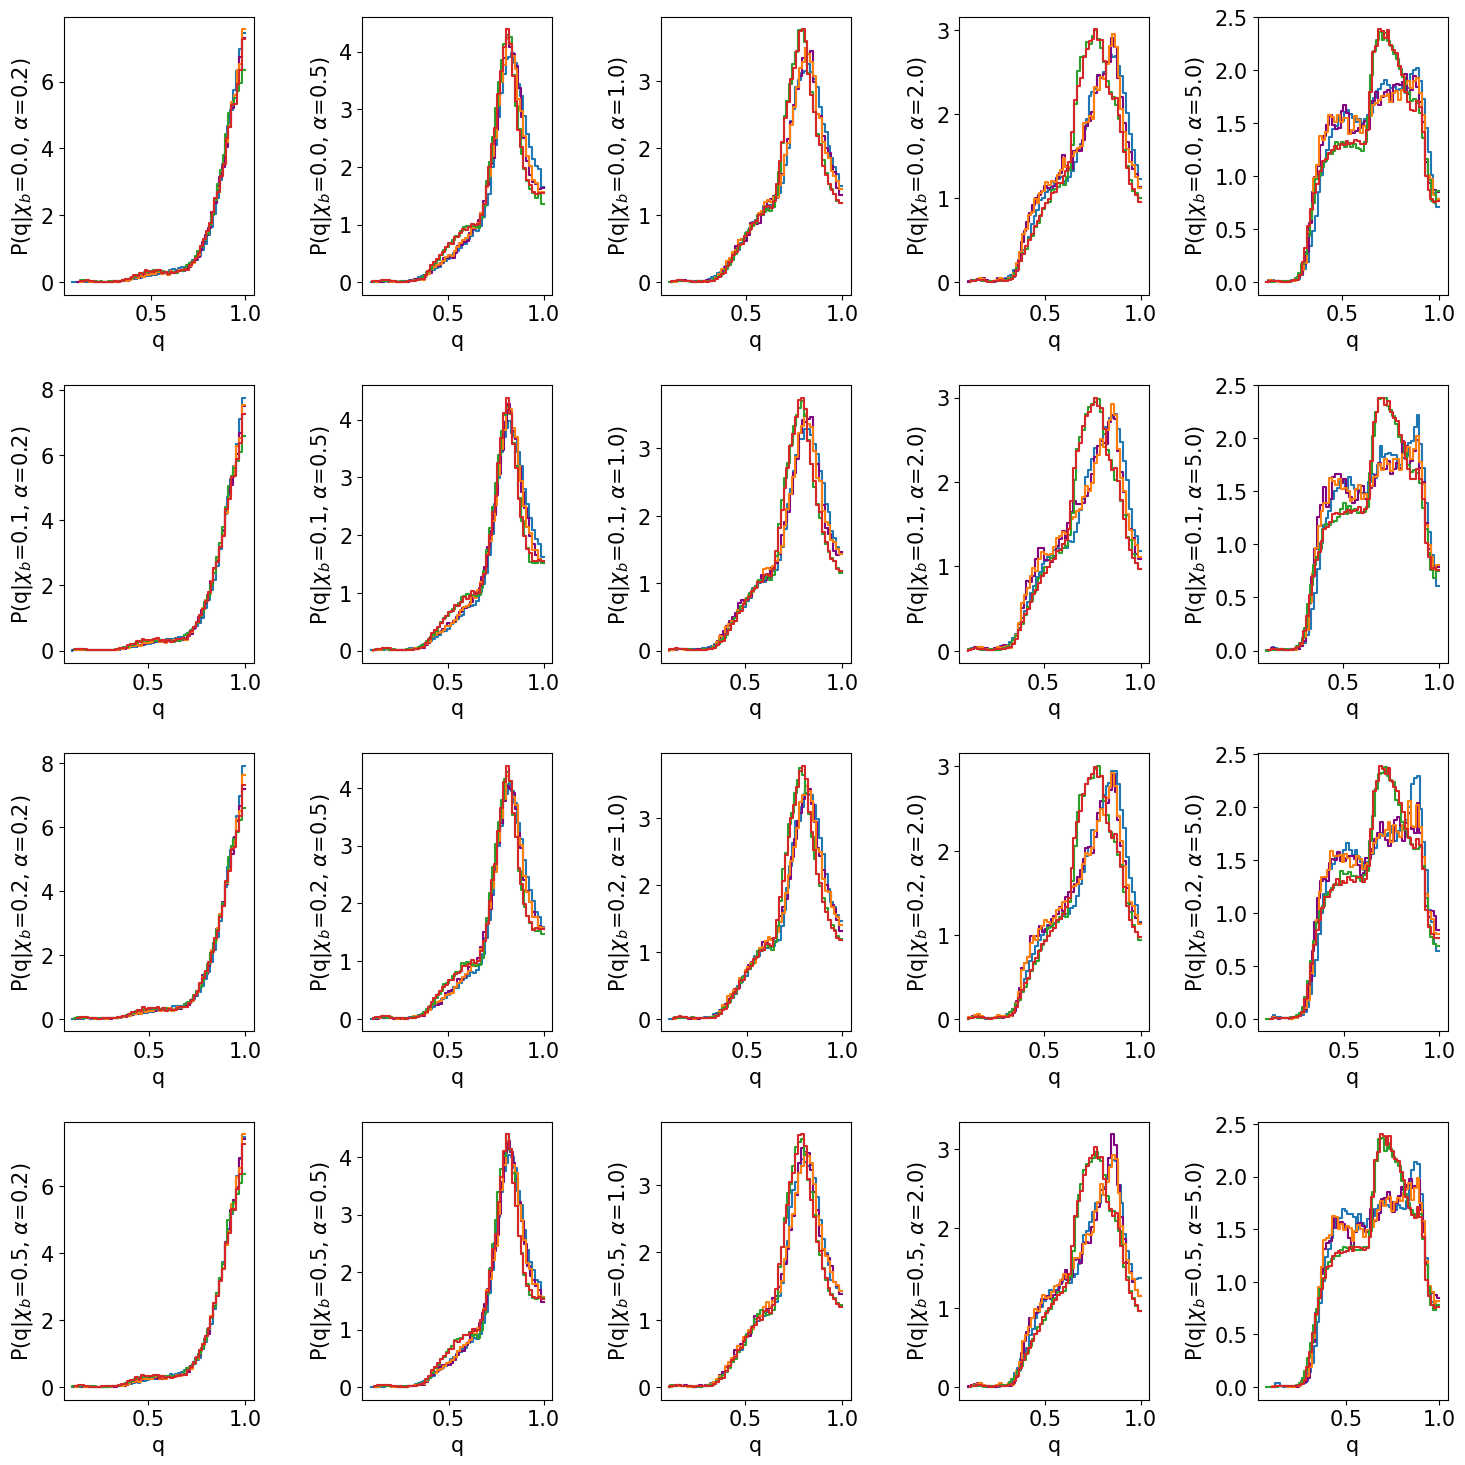

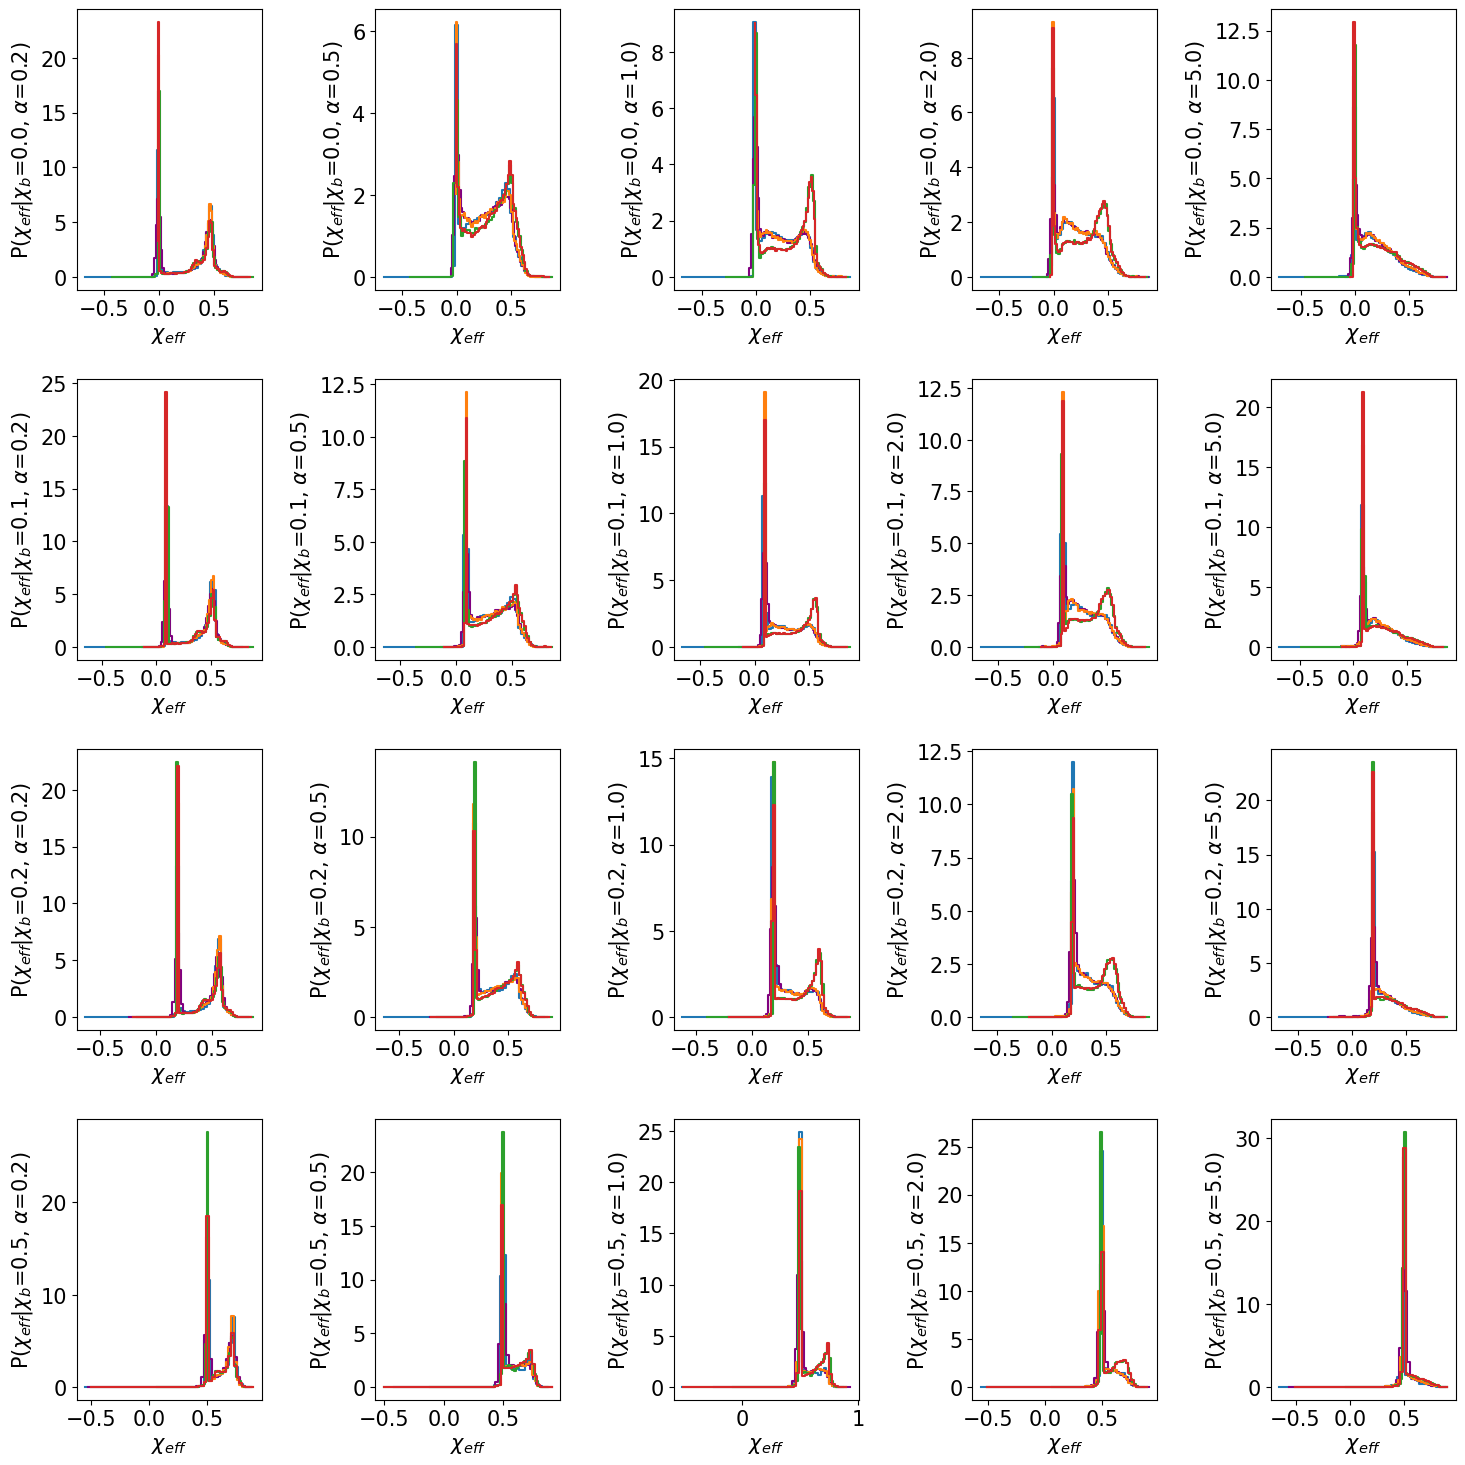

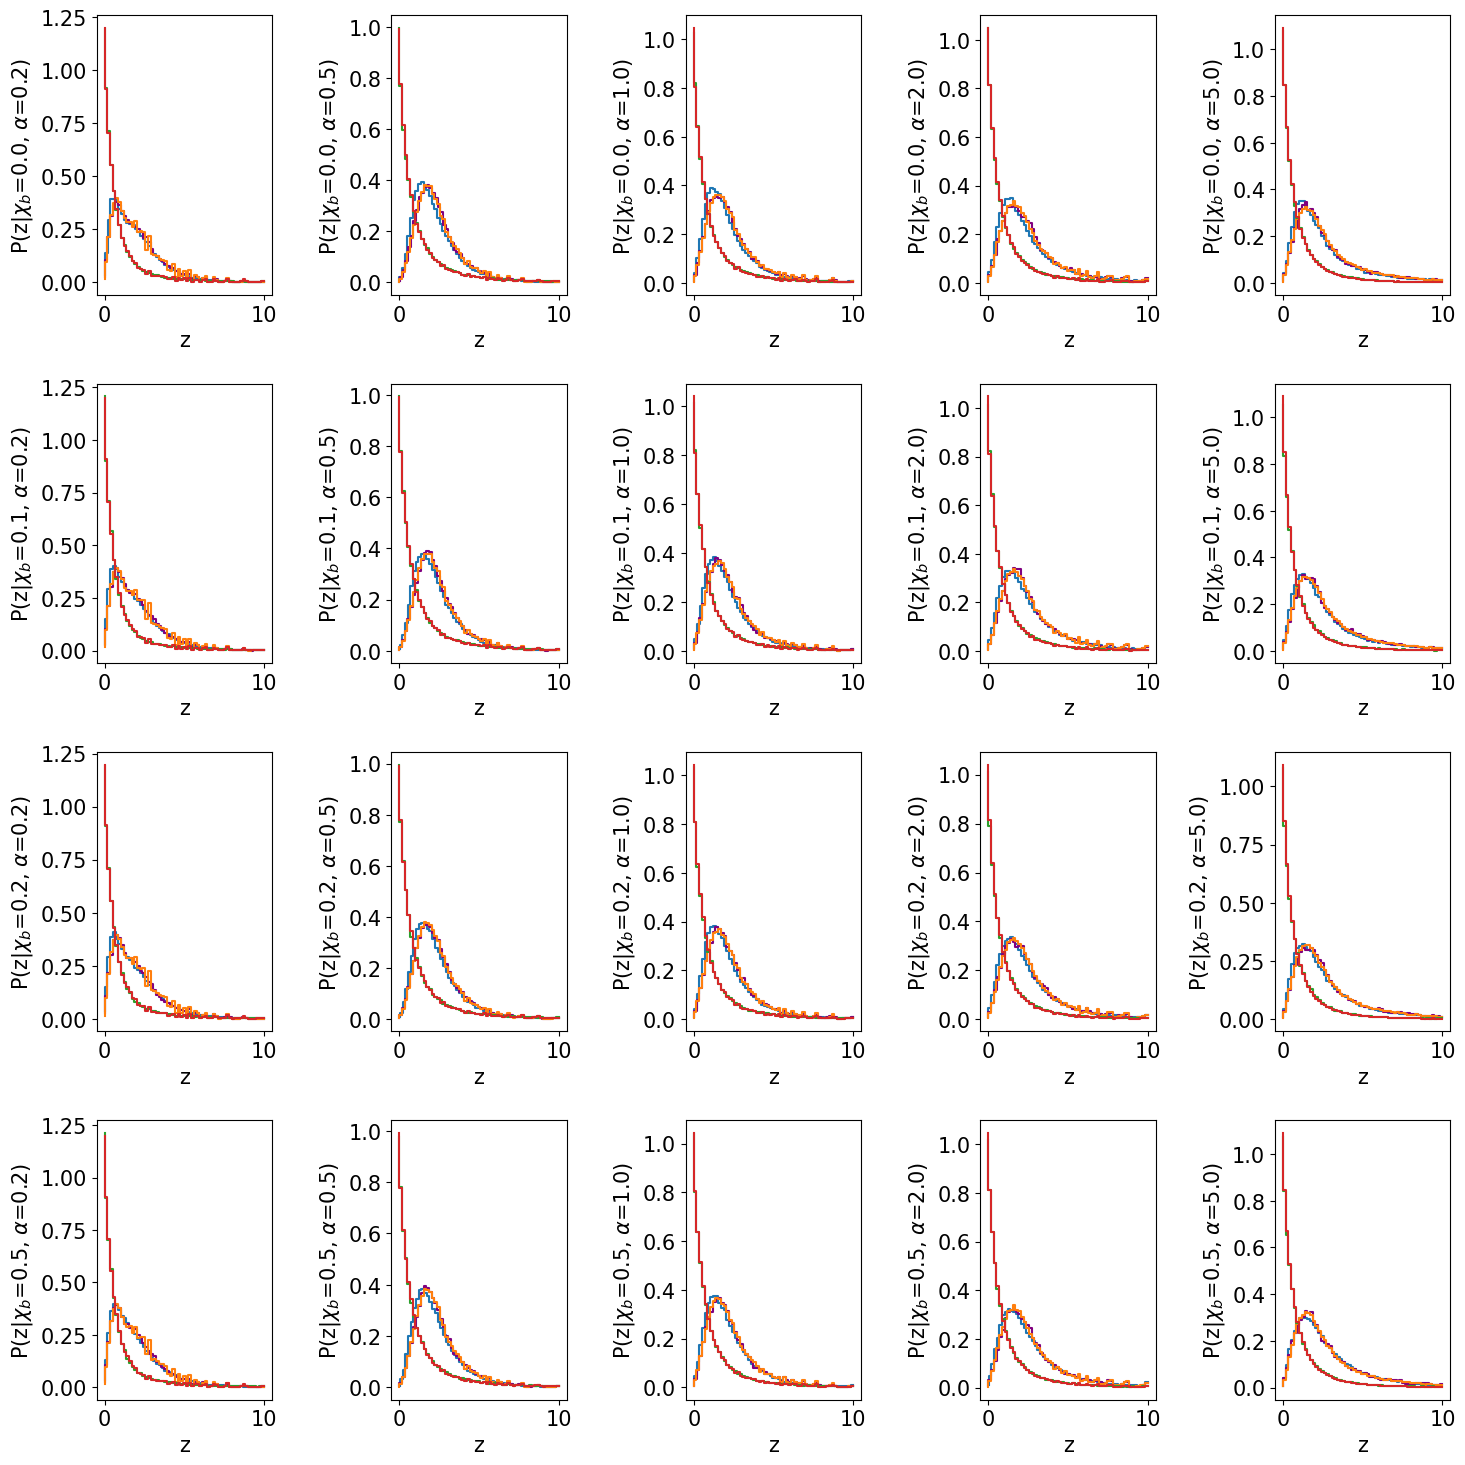

In [21]:
plt.rcParams["figure.figsize"] = (15,15)
plt.rcParams.update({'font.size': 15})
no_samples = 100000
no_bins = 60

fig_mchirp, ax_m = plt.subplots(4,5)
fig_q, ax_q = plt.subplots(4,5)
fig_c, ax_c = plt.subplots(4,5)
fig_z, ax_z = plt.subplots(4,5)

param_label = ['$\mathcal{M}$ /$M_{\odot}$','q', '$\chi_{eff}$', 'z']

for chi_b_id, xb in enumerate(chi_b):
    for alpha_id, a in enumerate(alpha_CE):
        flow_samples_stack = flow.flow.sample(np.array([xb,a]), no_samples)
        flow_mchirp = flow.expistic(flow_samples_stack[:,0], flow.mappings[0], flow.mappings[1])
        flow_q = flow.expistic(flow_samples_stack[:,1], flow.mappings[2])
        flow_chieff = np.tanh(flow_samples_stack[:,2])
        flow_z = flow.expistic(flow_samples_stack[:,3], flow.mappings[4], flow.mappings[5])

        mapped_flow_samples = [flow_mchirp,flow_q,flow_chieff,flow_z]

        wflow_samples_stack = flow.flow.sample(np.array([xb,a]), no_samples)
        wflow_mchirp = flow.expistic(wflow_samples_stack[:,0], flow.mappings[0], flow.mappings[1])
        wflow_q = flow.expistic(wflow_samples_stack[:,1], flow.mappings[2])
        wflow_chieff = np.tanh(wflow_samples_stack[:,2])
        wflow_z = flow.expistic(wflow_samples_stack[:,3], flow.mappings[4], flow.mappings[5])

        wmapped_flow_samples = [wflow_mchirp,wflow_q,wflow_chieff,wflow_z]
        wkde_samples = KDE_models['CE'][submodels_dict[0][chi_b_id]][submodels_dict[1][alpha_id]].sample(no_samples)


        for i, ax in enumerate([ax_m,ax_q,ax_c,ax_z]):
            flow_distr, bin_edges = np.histogram(mapped_flow_samples[i], bins=no_bins, density=True)
            known_distr, bin_edges_known =np.histogram(models_dict[(chi_b_id,alpha_id)][:][param[i]], bins=no_bins, density=True)

            wflow_distr, wbin_edges = np.histogram(wmapped_flow_samples[i], bins=no_bins, density=True)
            wkde_distr, wbin_edges_KDE = np.histogram(wkde_samples[:,i], bins=no_bins, density=True)
            wknown_distr, wbin_edges_known =np.histogram(models_dict[(chi_b_id,alpha_id)][:][param[i]], bins=no_bins, density=True, weights=weights_dict[(chi_b_id,alpha_id)][:])
            ax[chi_b_id,alpha_id].step(np.linspace(wbin_edges[0],wbin_edges[-1],no_bins),wflow_distr, label='weighted flow')
            ax[chi_b_id,alpha_id].step(np.linspace(wbin_edges_KDE[0],wbin_edges_KDE[-1],no_bins),wkde_distr,label='KDE', color='purple')
            ax[chi_b_id,alpha_id].step(np.linspace(wbin_edges_known[0],wbin_edges_known[-1],no_bins),wknown_distr,label='underlying')

            ax[chi_b_id,alpha_id].step(np.linspace(bin_edges[0],bin_edges[-1],no_bins),flow_distr, label='flow')
            ax[chi_b_id,alpha_id].step(np.linspace(bin_edges_known[0],bin_edges_known[-1],no_bins),known_distr,label='underlying')
            #ax[chi_b_id,alpha_id].set_title(fr'$\chi_b$={xb} and $\alpha$={a}')
            ax[chi_b_id,alpha_id].set_xlabel(fr'{param_label[i]}')
            ax[chi_b_id,alpha_id].set_ylabel(fr'P({param_label[i]}|$\chi_b$={xb}, $\alpha$={a})')
            #ax[chi_b_id,alpha_id].legend()
            fig_mchirp.tight_layout(pad=1.3)
            fig_c.tight_layout(pad=1.3)
            fig_q.tight_layout(pad=1.3)
            fig_z.tight_layout(pad=1.3)

## Cosmo weighted Distributions - CE

/tmp/ipykernel_4083804/568462263.py:39: UserWarning: The figure layout has changed to tight
  fig_mchirp.tight_layout(pad=1.3)
/tmp/ipykernel_4083804/568462263.py:40: UserWarning: The figure layout has changed to tight
  fig_c.tight_layout(pad=1.3)
/tmp/ipykernel_4083804/568462263.py:41: UserWarning: The figure layout has changed to tight
  fig_q.tight_layout(pad=1.3)
/tmp/ipykernel_4083804/568462263.py:42: UserWarning: The figure layout has changed to tight
  fig_z.tight_layout(pad=1.3)


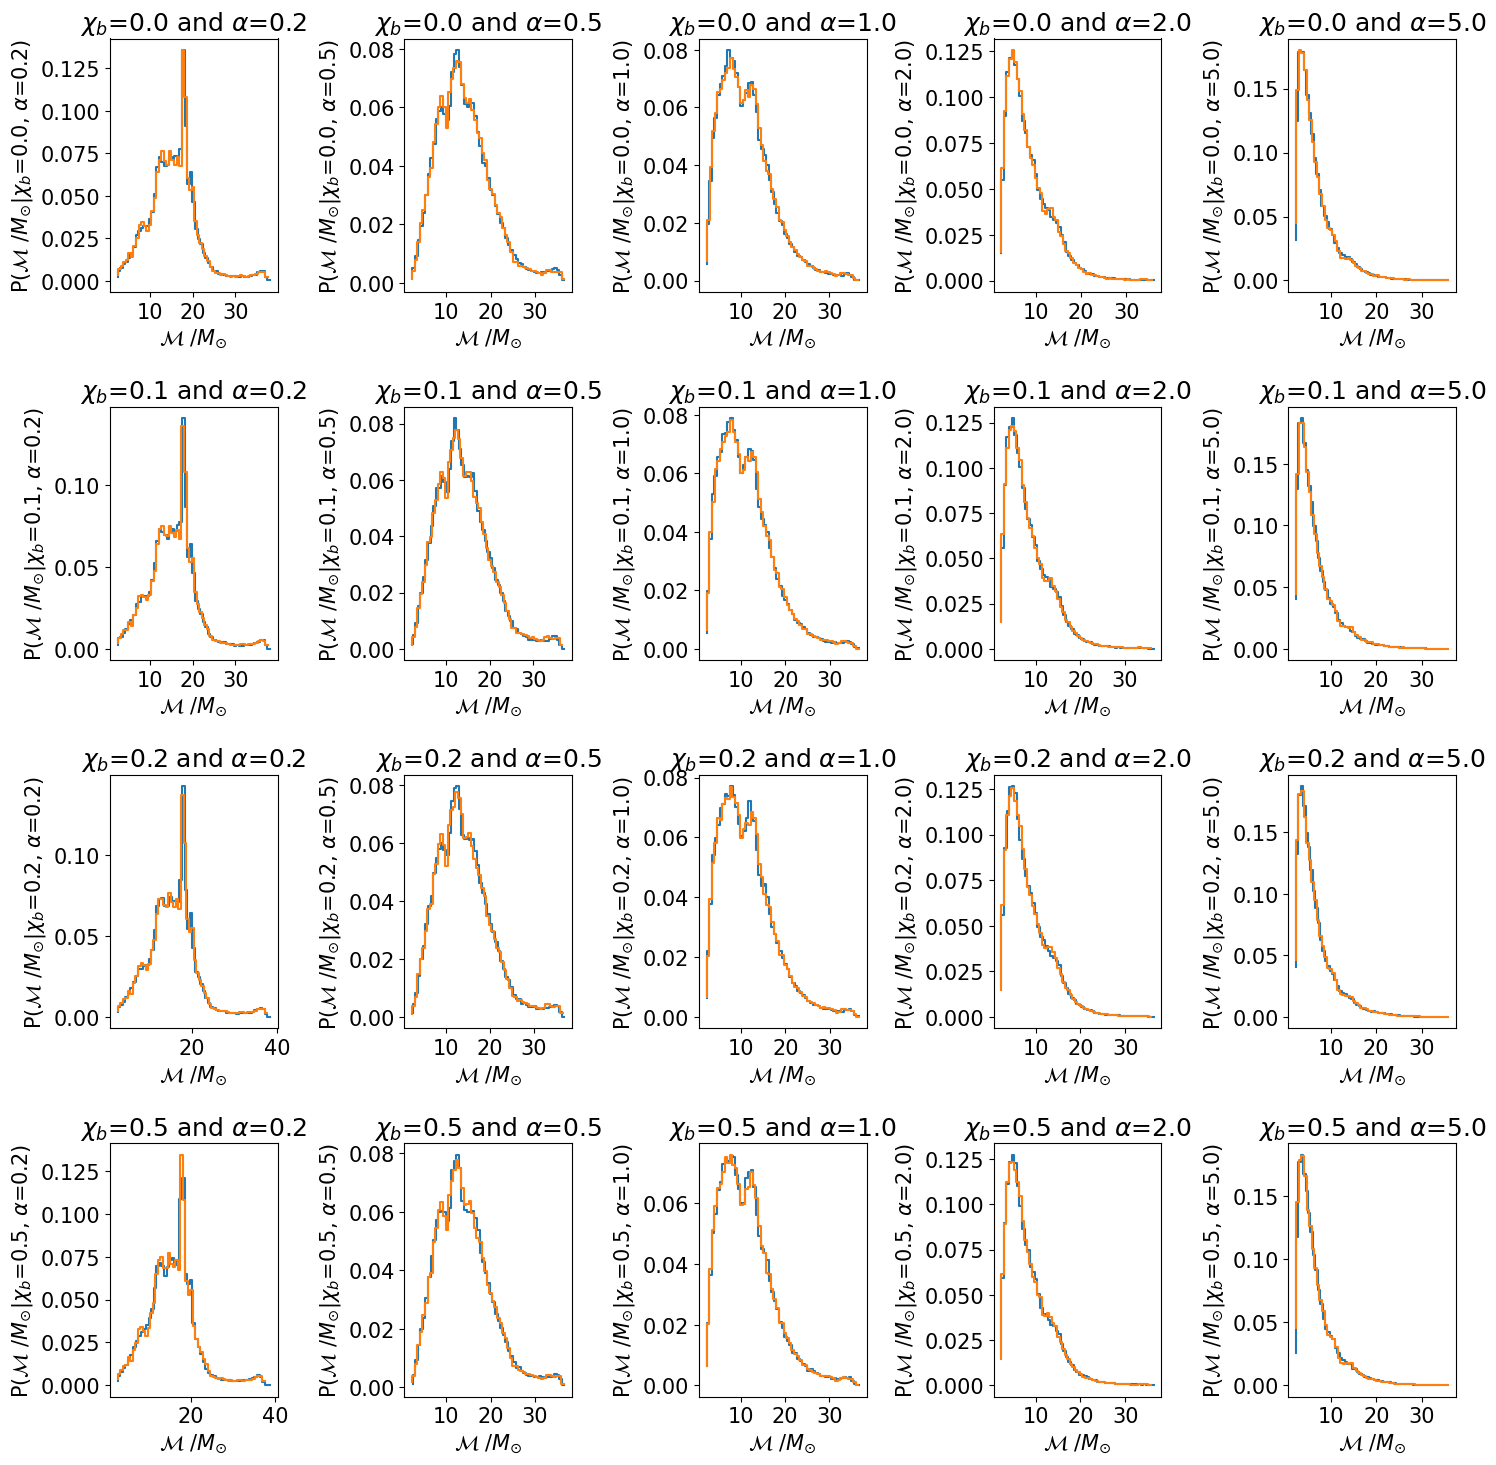

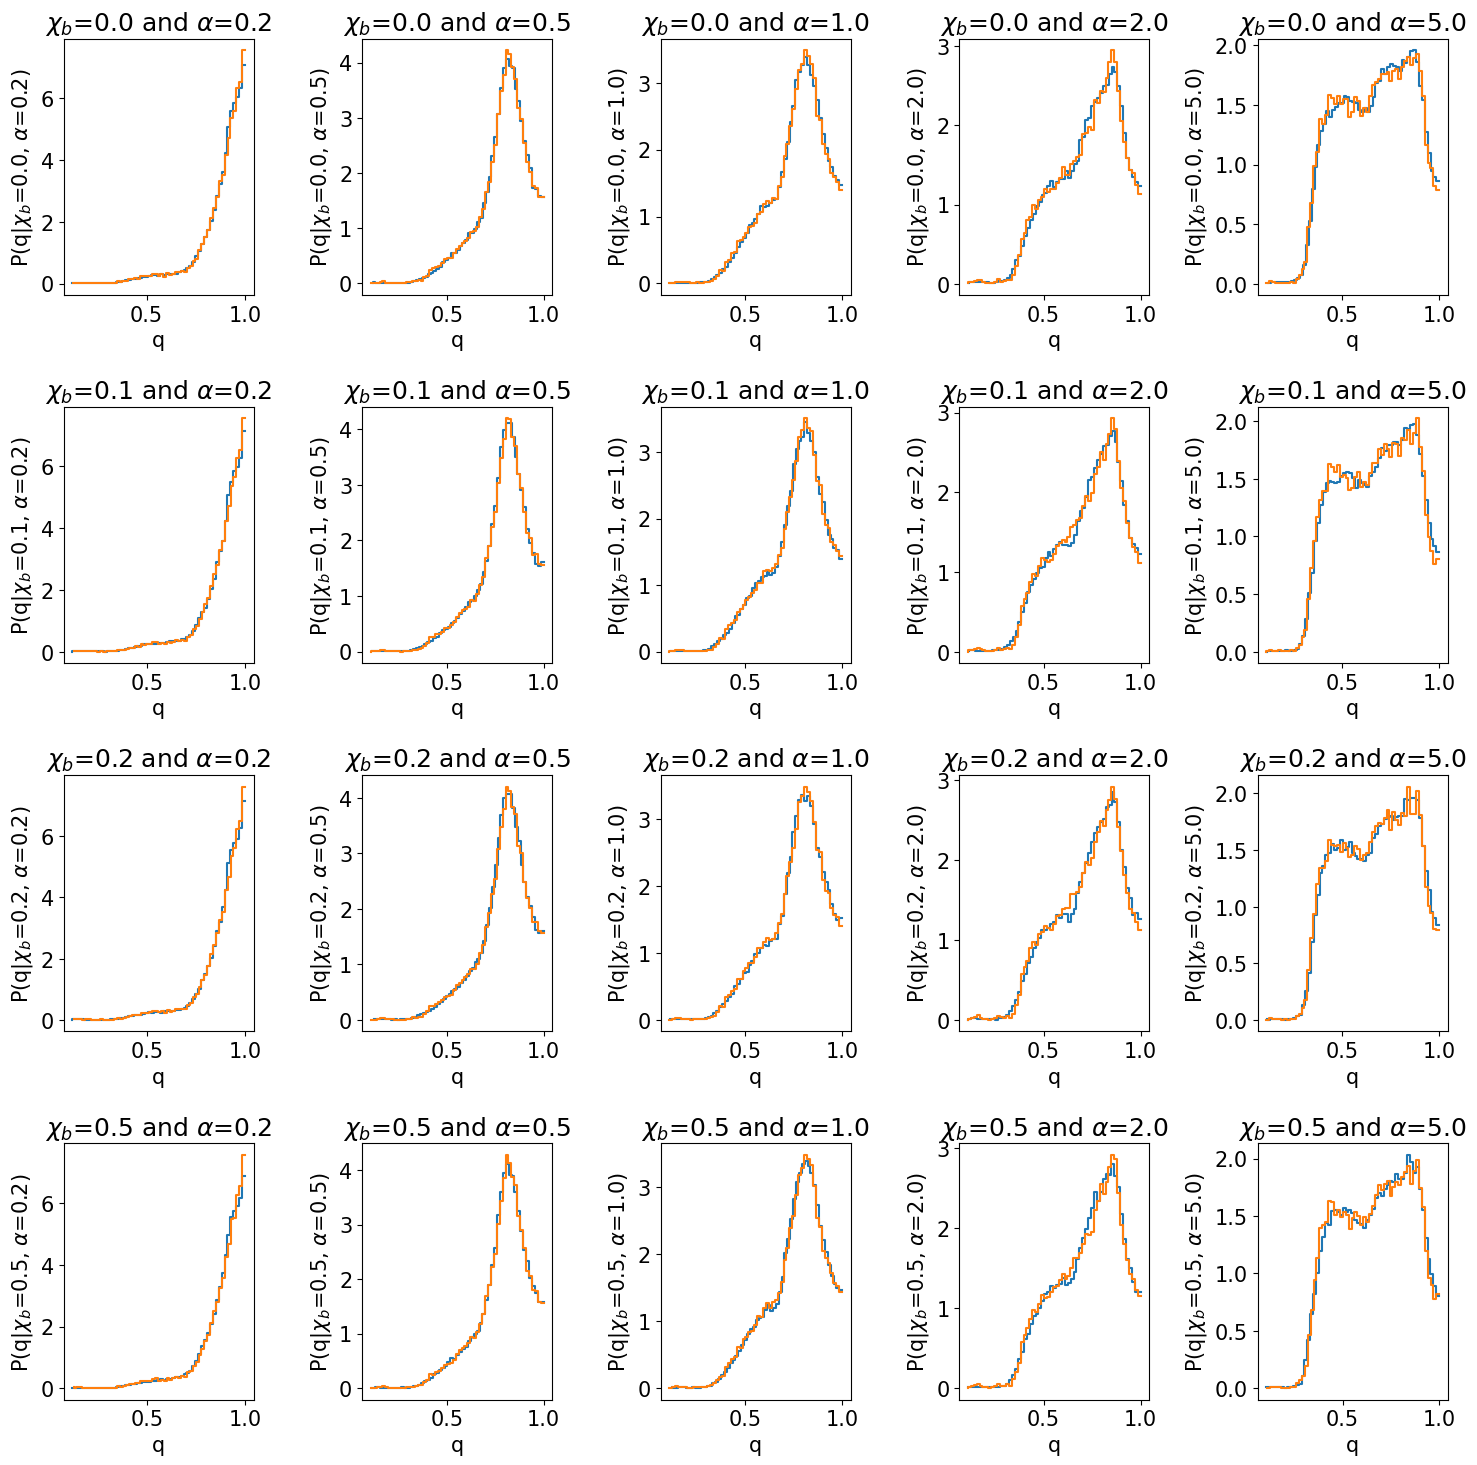

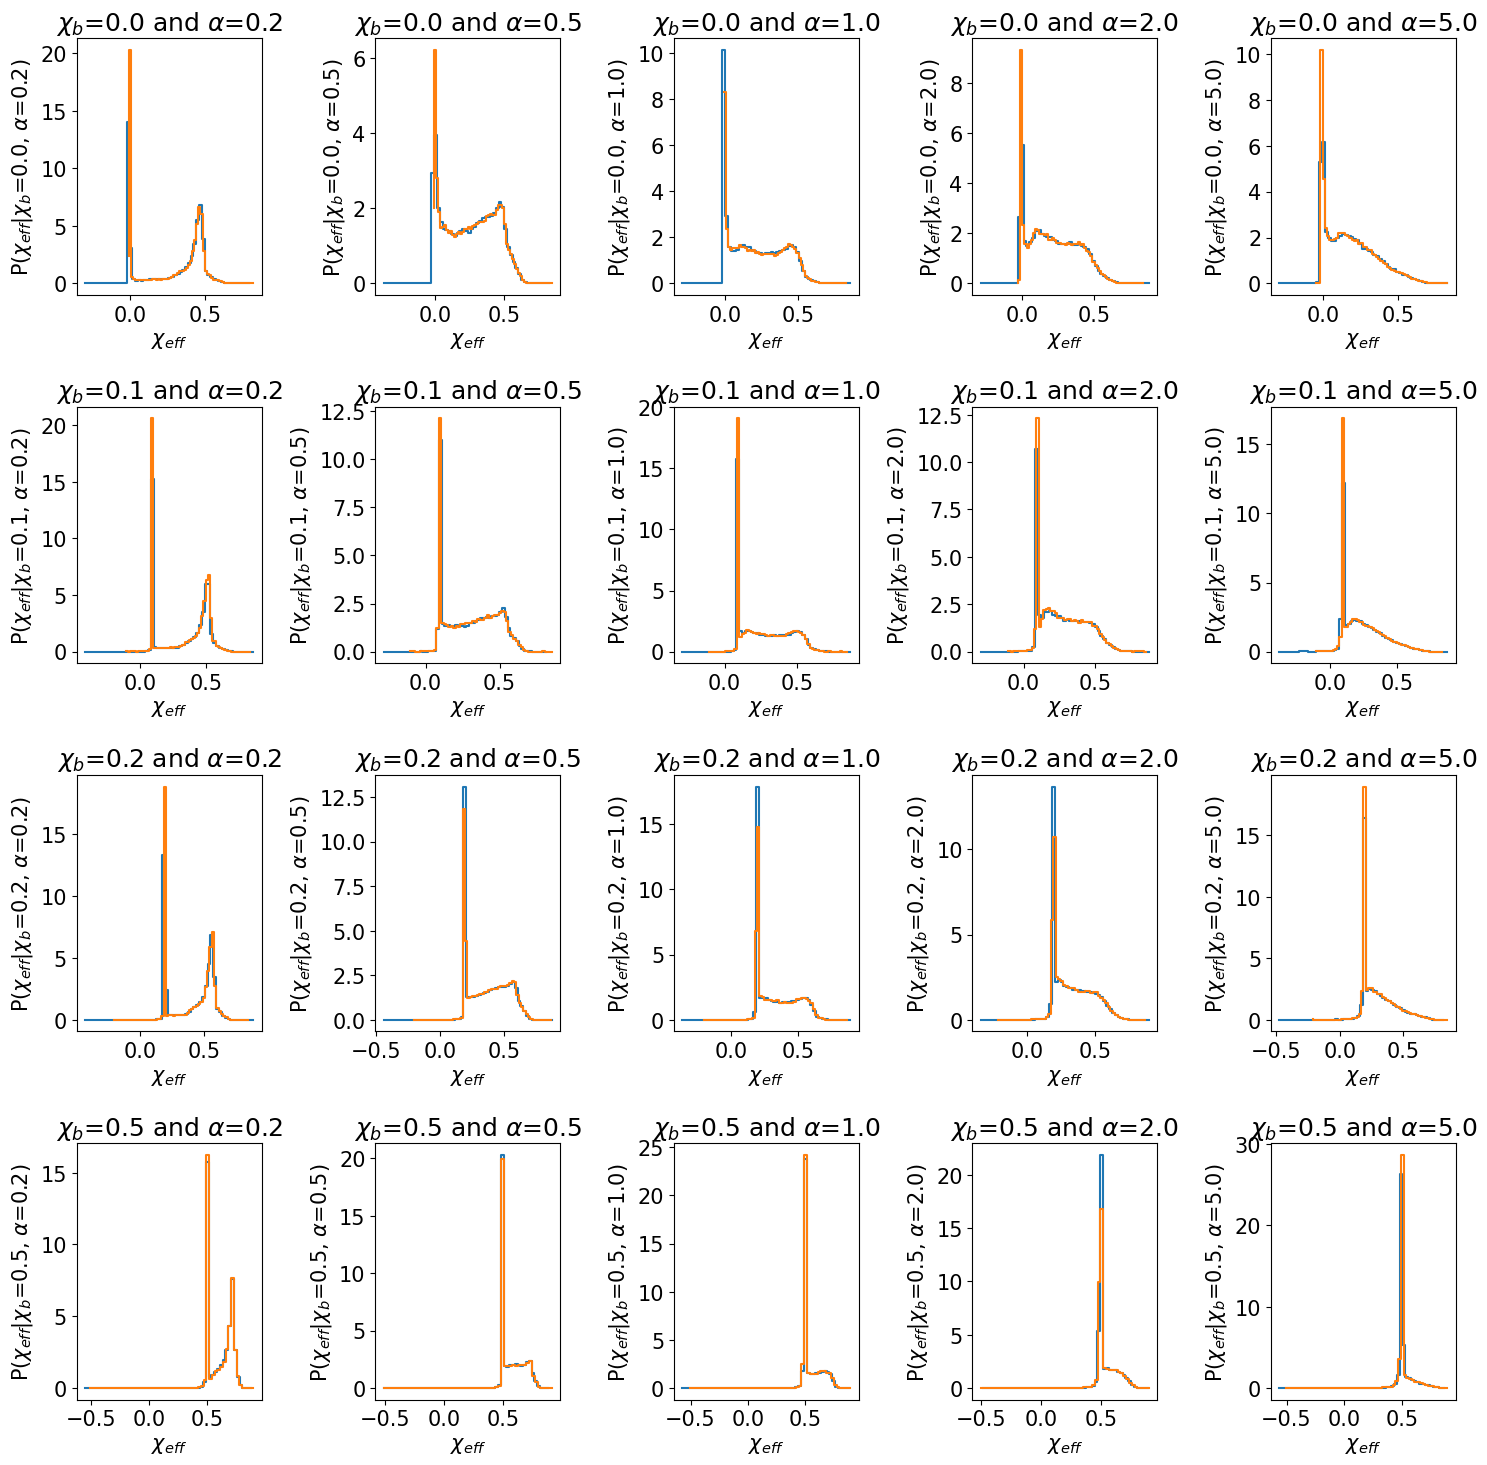

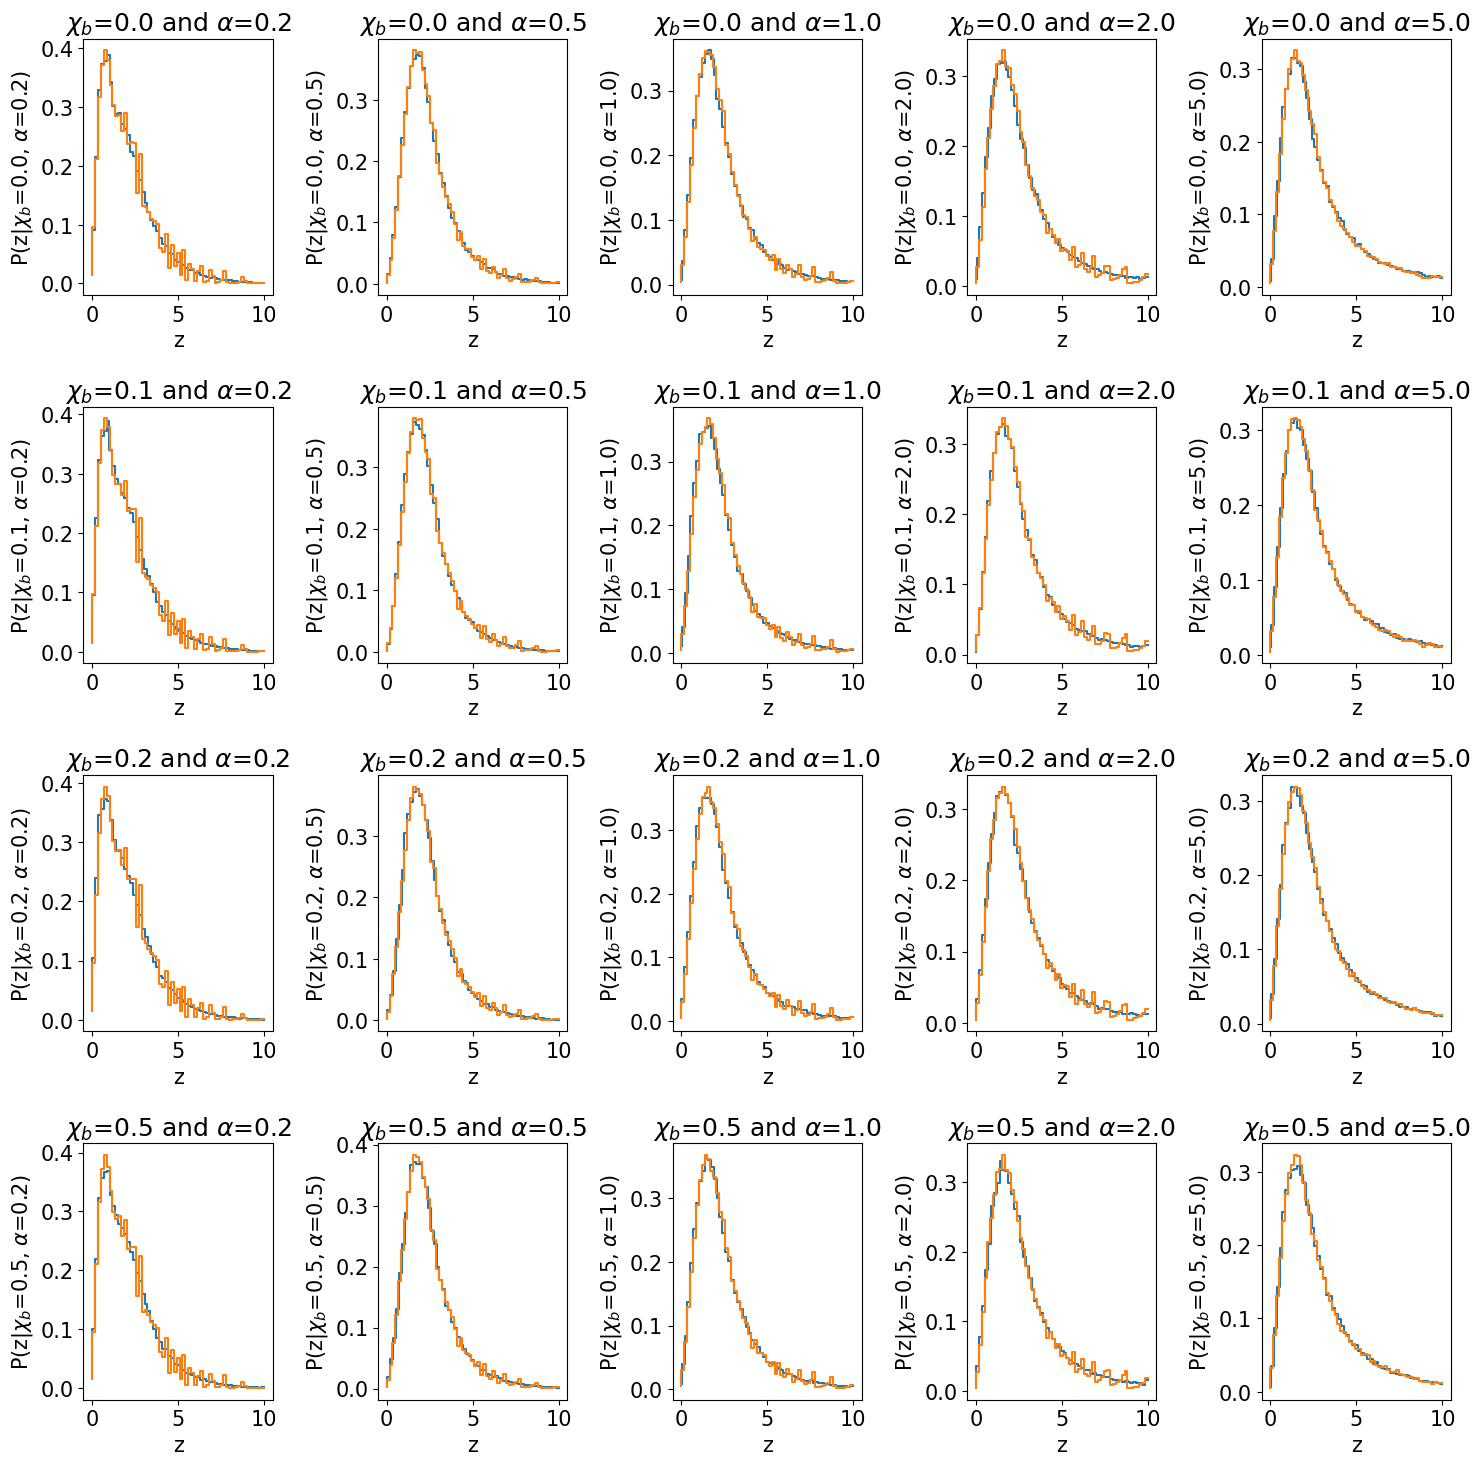

In [9]:
plt.rcParams["figure.figsize"] = (15,15)
plt.rcParams.update({'font.size': 15})
no_samples = 100000
no_bins = 60
alpha_CE = [0.2,0.5,1.0,2.,5.]


fig_mchirp, ax_m = plt.subplots(4,5)
fig_q, ax_q = plt.subplots(4,5)
fig_c, ax_c = plt.subplots(4,5)
fig_z, ax_z = plt.subplots(4,5)

param_label = ['$\mathcal{M}$ /$M_{\odot}$','q', '$\chi_{eff}$', 'z']

for chi_b_id, xb in enumerate(chi_b):
    for alpha_id, a in enumerate(alpha_CE):
        flow_samples_stack = flow.flow.sample(np.array([xb,np.log(a)]), no_samples)
        flow_mchirp = flow.expistic(flow_samples_stack[:,0], flow.mappings[0], flow.mappings[1])
        flow_q = flow.expistic(flow_samples_stack[:,1], flow.mappings[2])
        flow_chieff = np.tanh(flow_samples_stack[:,2])
        flow_z = flow.expistic(flow_samples_stack[:,3], flow.mappings[4], flow.mappings[5])

        mapped_flow_samples = [flow_mchirp,flow_q,flow_chieff,flow_z]

        #kde_samples = KDE_models['CE'][submodels_dict[0][chi_b_id]][submodels_dict[1][alpha_id]].sample(no_samples)

        for i, ax in enumerate([ax_m,ax_q,ax_c,ax_z]):
            flow_distr, bin_edges = np.histogram(mapped_flow_samples[i], bins=no_bins, density=True)
            #kde_distr, bin_edges_KDE = np.histogram(kde_samples[:,i], bins=no_bins, density=True)
            known_distr, bin_edges_known =np.histogram(models_dict[(chi_b_id,alpha_id)][:][param[i]], bins=no_bins, density=True, weights=weights_dict[(chi_b_id,alpha_id)][:])
            ax[chi_b_id,alpha_id].step(np.linspace(bin_edges[0],bin_edges[-1],no_bins),flow_distr, label='flow')
            #ax[chi_b_id,alpha_id].step(np.linspace(bin_edges_KDE[0],bin_edges_KDE[-1],no_bins),kde_distr,label='KDE', color='purple')
            ax[chi_b_id,alpha_id].step(np.linspace(bin_edges_known[0],bin_edges_known[-1],no_bins),known_distr,label='underlying')
            ax[chi_b_id,alpha_id].set_title(fr'$\chi_b$={xb} and $\alpha$={a}')
            ax[chi_b_id,alpha_id].set_xlabel(fr'{param_label[i]}')
            ax[chi_b_id,alpha_id].set_ylabel(fr'P({param_label[i]}|$\chi_b$={xb}, $\alpha$={a})')
            #ax[chi_b_id,alpha_id].set_yscale('log')
            #ax[chi_b_id,alpha_id].legend()
            fig_mchirp.tight_layout(pad=1.3)
            fig_c.tight_layout(pad=1.3)
            fig_q.tight_layout(pad=1.3)
            fig_z.tight_layout(pad=1.3)

## Corner Plots for 1 subpop

In [9]:
corner_kwargs = dict(
    bins=64,
    smooth=0.9,
    #quantiles=[0.16, 0.84],
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.0)),
    plot_density=True,
    plot_datapoints=True,
    fill_contours=True,
    show_titles=False,
    hist_kwargs=dict(density=True),
    labels=param,
    color='teal'
)

In [11]:
corner_kwargs_kde = dict(
    bins=64,
    smooth=0.9,
    #quantiles=[0.16, 0.84],
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.0)),
    plot_density=True,
    plot_datapoints=True,
    fill_contours=True,
    show_titles=False,
    hist_kwargs=dict(density=True),
    labels=param,
    color='purple'
)


## Corner plot CE

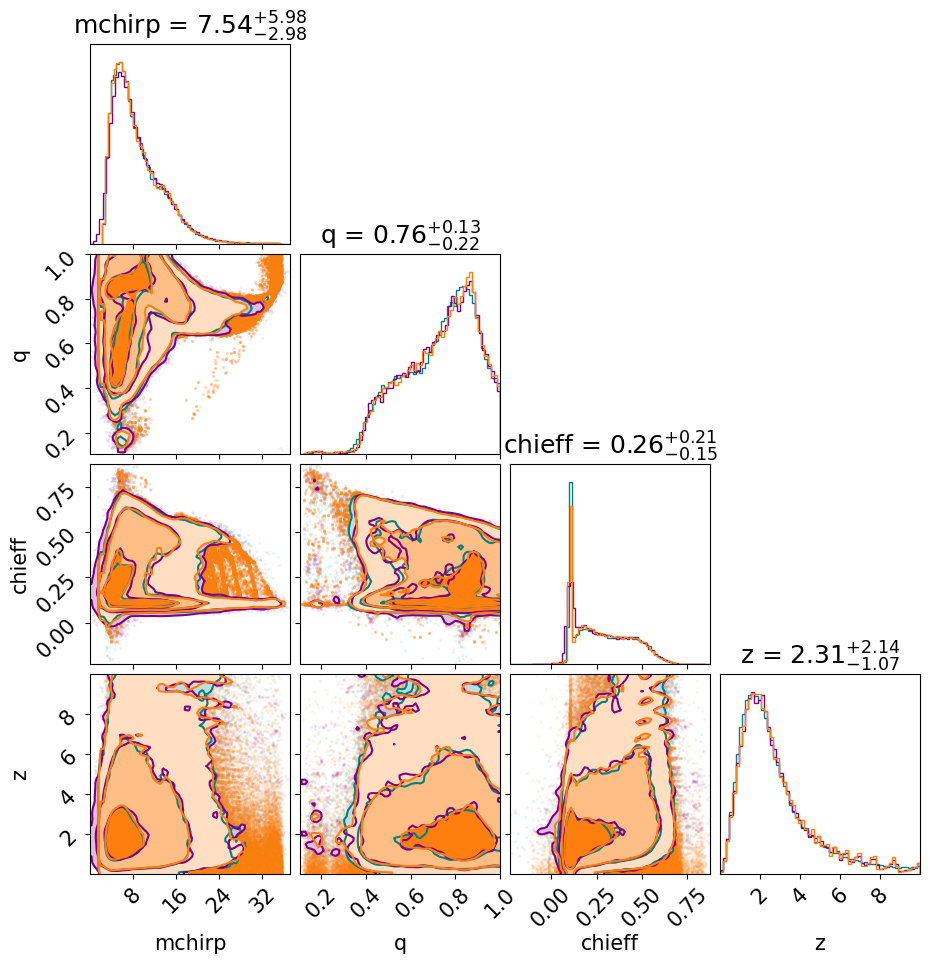

In [35]:
#sample flow
no_samples=100000
hyperparam_idxs = (1,3)
kwargs = deepcopy(corner_kwargs)
kwargs["color"] = "C1"
kwargs["hist_kwargs"]["color"] = "C1"

flow_samples_stack = flow.flow.sample(np.array([0.1,np.log(2.)]),no_samples)
flow_samples_stack[:,0] = flow.expistic(flow_samples_stack[:,0], flow.mappings[0], flow.mappings[1])
flow_samples_stack[:,1] = flow.expistic(flow_samples_stack[:,1], flow.mappings[2])
flow_samples_stack[:,2] = np.tanh(flow_samples_stack[:,2])
flow_samples_stack[:,3] = flow.expistic(flow_samples_stack[:,3], flow.mappings[4], flow.mappings[5])


kde_samples = KDE_models['CE'][submodels_dict[0][hyperparam_idxs[0]]][submodels_dict[1][hyperparam_idxs[1]]].sample(no_samples)

fig = corner.corner(flow_samples_stack.numpy(), **corner_kwargs)
fig =corner.corner(kde_samples, fig=fig, **corner_kwargs_kde)
fig =corner.corner(models_dict[hyperparam_idxs], fig=fig, weights=weights_dict[hyperparam_idxs][:], **kwargs)


## Corner plot non-CE

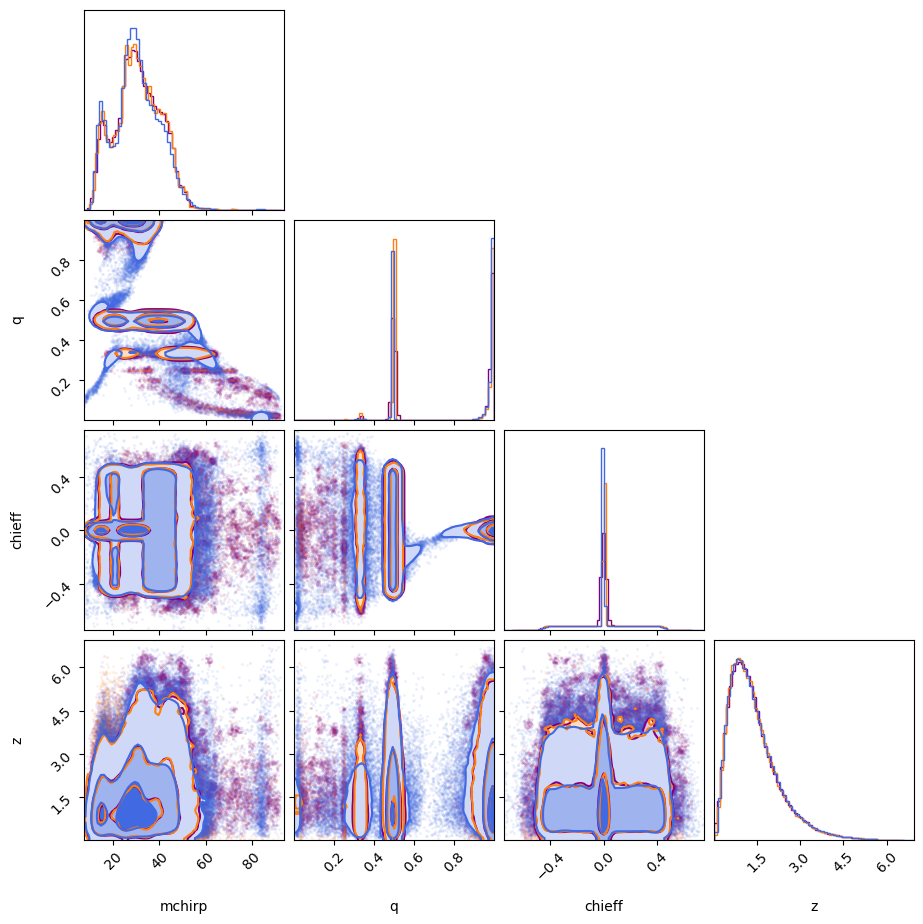

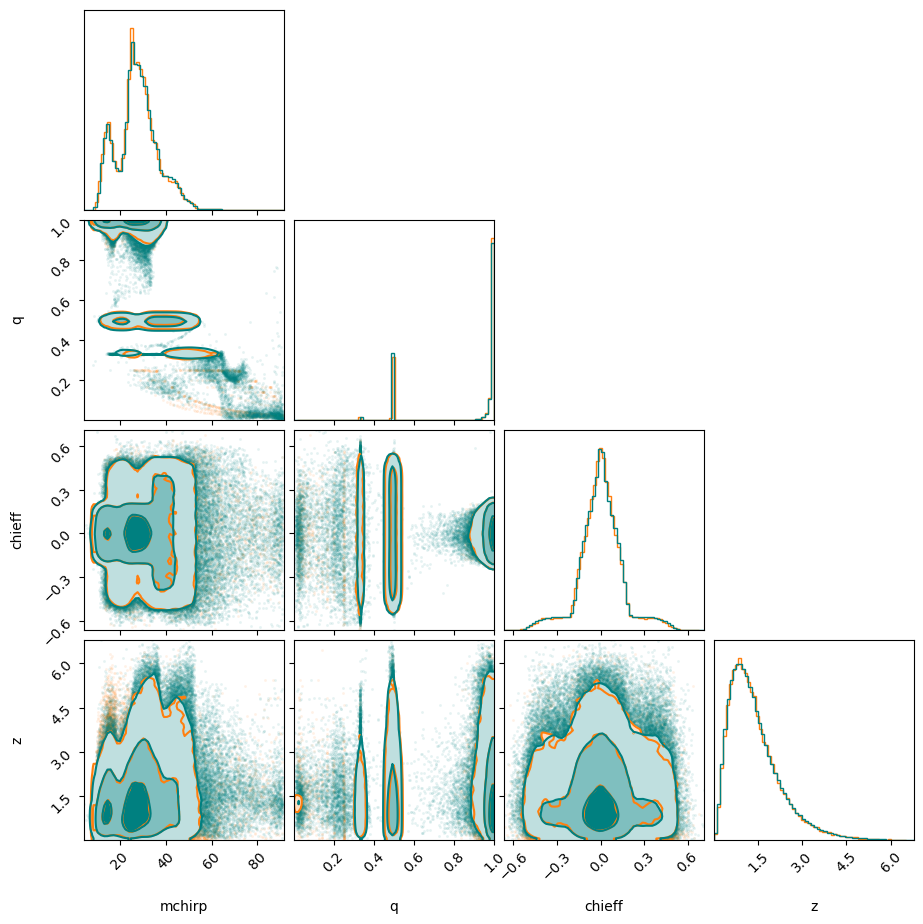

In [18]:
#sample flow
no_samples=1000000
hyperparam_idxs = (2)
kwargs = deepcopy(corner_kwargs)
kwargs["color"] = "C1"
kwargs["hist_kwargs"]["color"] = "C1"

flow_samples_stack = flow.flow.sample(np.array([0.2]), no_samples)
flow_samples_stack[:,0] = flow.expistic(flow_samples_stack[:,0], flow.mappings[0], flow.mappings[1])
flow_samples_stack[:,1] = flow.expistic(flow_samples_stack[:,1], flow.mappings[2])
flow_samples_stack[:,2] = np.tanh(flow_samples_stack[:,2])
flow_samples_stack[:,3] = flow.expistic(flow_samples_stack[:,3], flow.mappings[4], flow.mappings[5])

kde_samples = KDE_models[channel_label][submodels_dict[0][hyperparam_idxs]].sample(no_samples)

#fig =corner.corner(kde_samples,  **corner_kwargs_kde)
fig =corner.corner(models_dict[hyperparam_idxs], weights=weights_dict[hyperparam_idxs][:], **kwargs)
fig = corner.corner(flow_samples_stack.numpy(), fig=fig, **corner_kwargs)